# Students Performance in Exams - Data Analysis

# Students Performance Analysis

## Project Overview

This project analyzes the performance of 1,000 students across three subjects: Mathematics, Reading, and Writing.

The goal is to explore the factors associated with students' academic performance and identify meaningful patterns in the data.

### Objectives

- Analyze students' performance across different demographic groups.
- Investigate the impact of test preparation on exam scores.
- Examine the relationship between parental education and student performance.
- Analyze the relationship between math, reading, and writing scores.
- Identify key insights that may help understand factors associated with academic performance.

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Loading and Inspecting the Dataset

In [64]:
df = pd.read_csv("/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 1. Dataset Overview

In [65]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 1000
Number of columns: 8


In [66]:
df.head
df.shape
df.info()# no missing value
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## 2. Key Performance Indicators (KPIs)

In [67]:
average_math = df["math score"].mean()
average_reading = df["reading score"].mean()
average_writing = df["writing score"].mean()

overall_average = df[
    ["math score", "reading score", "writing score"]
].mean().mean()

preparation_rate = (
    df["test preparation course"].eq("completed").mean() * 100
)

print(f"Average Math Score: {average_math:.2f}")
print(f"Average Reading Score: {average_reading:.2f}")
print(f"Average Writing Score: {average_writing:.2f}")
print(f"Overall Average Score: {overall_average:.2f}")
print(f"Test Preparation Completion Rate: {preparation_rate:.2f}%")

Average Math Score: 66.09
Average Reading Score: 69.17
Average Writing Score: 68.05
Overall Average Score: 67.77
Test Preparation Completion Rate: 35.80%


## 3. Score Distribution

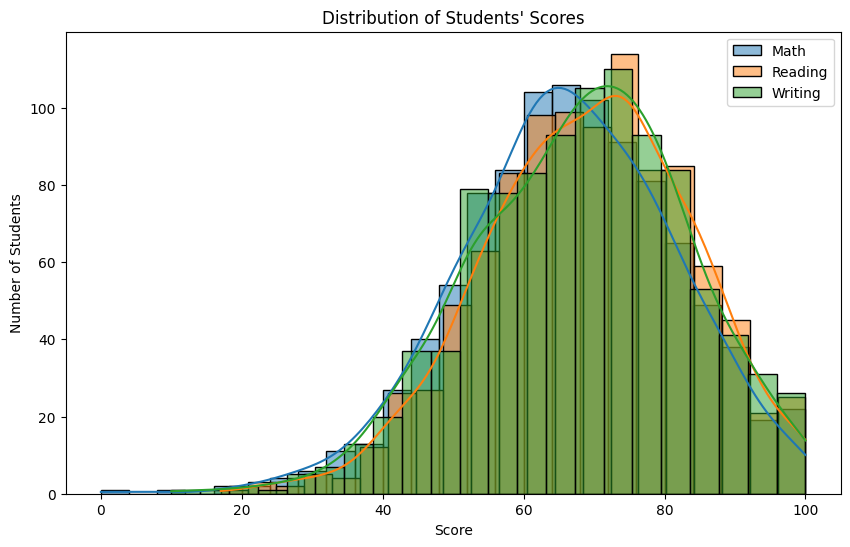

In [68]:
plt.figure(figsize=(10, 6))

sns.histplot(df["math score"], kde=True, label="Math")
sns.histplot(df["reading score"], kde=True, label="Reading")
sns.histplot(df["writing score"], kde=True, label="Writing")

plt.title("Distribution of Students' Scores")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.legend()
plt.show()

### Insight

The three score distributions are generally centered around the middle-to-upper range of the scoring scale. Reading and writing scores tend to be slightly higher than math scores, which is consistent with the overall average scores.

The distributions also show that students' performance varies considerably, indicating differences in academic achievement across the dataset.

## 4. Performance by Gender

In [69]:
gender_scores = df.groupby("gender")[
    ["math score", "reading score", "writing score"]
].mean()

gender_scores

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


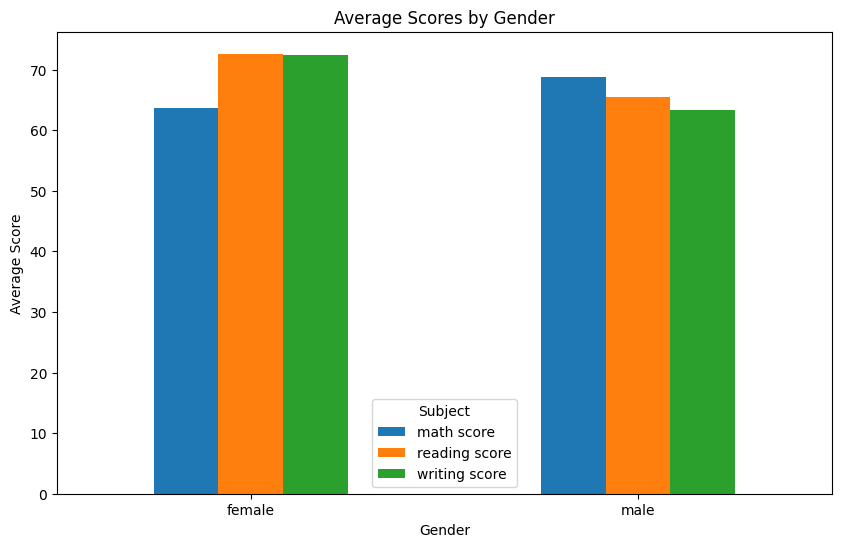

In [70]:
gender_scores.plot(kind="bar", figsize=(10, 6))

plt.title("Average Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subject")
plt.show()

### Insight

Male students have a higher average score in mathematics, while female students achieve higher average scores in reading and writing. This indicates that performance patterns differ across subjects and gender groups.

## 5. Impact of Test Preparation on Performance

In [71]:
prep_scores = df.groupby("test preparation course")[
    ["math score", "reading score", "writing score"]
].mean()

prep_scores


,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


In [72]:
score_difference = (
    prep_scores.loc["completed"] - prep_scores.loc["none"]
)

score_difference

,0
math score,5.617649
reading score,7.359587
writing score,9.914322


In [73]:
percentage_improvement = (
    (prep_scores.loc["completed"] - prep_scores.loc["none"])
    / prep_scores.loc["none"] * 100
)

percentage_improvement

,0
math score,8.766908
reading score,11.061348
writing score,15.369928


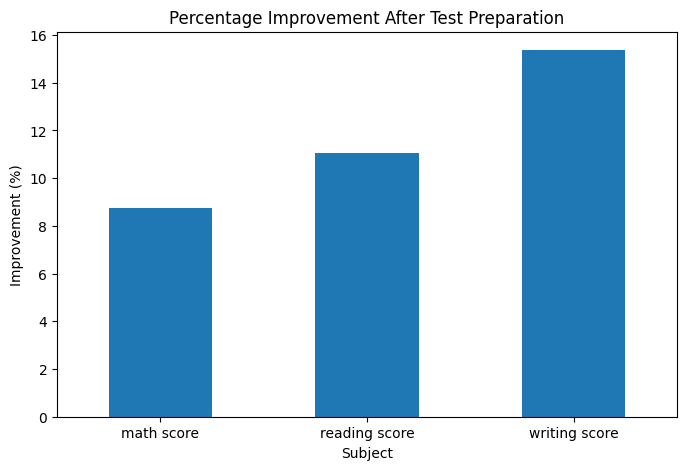

In [74]:
percentage_improvement.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Percentage Improvement After Test Preparation")
plt.xlabel("Subject")
plt.ylabel("Improvement (%)")
plt.xticks(rotation=0)
plt.show()

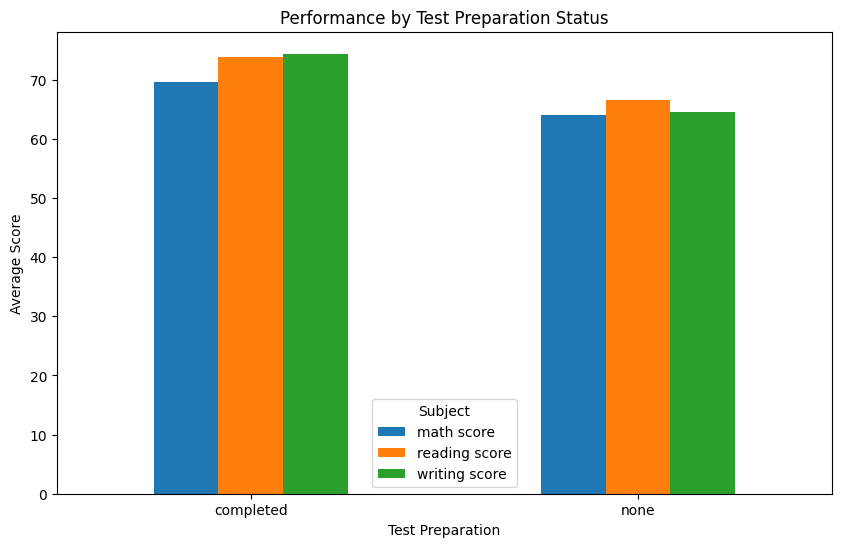

In [75]:
prep_scores.plot(kind="bar", figsize=(10, 6))

plt.title("Performance by Test Preparation Status")
plt.xlabel("Test Preparation")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subject")
plt.show()

### Insight

Students who completed the test preparation course achieved higher average scores in all three subjects.

The largest improvement was observed in writing, where students who completed the course scored 9.91 points higher on average, representing a 15.37% improvement compared with students who did not complete the course.

Reading showed a 7.36-point difference (11.06%), while math showed a 5.62-point difference (8.77%).

Overall, completing the test preparation course is strongly associated with better academic performance across all three subjects.

## 2. Exploratory Data Analysis (EDA)

### Question 1: Which gender performs better in each subject?

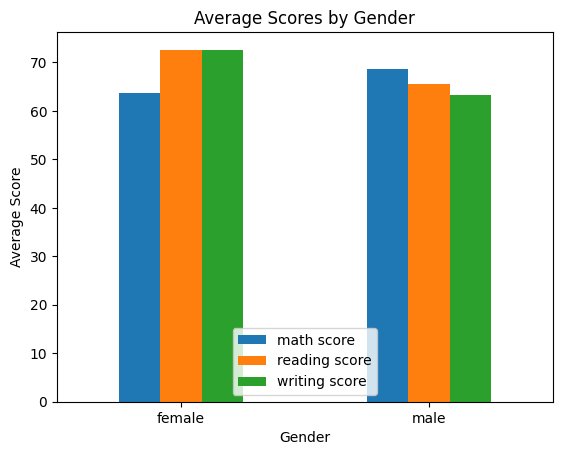

In [76]:
df.groupby("gender")[["math score", "reading score", "writing score"]].mean()
df.groupby("gender")[["math score", "reading score", "writing score"]].mean().plot(
    kind="bar"
)

plt.title("Average Scores by Gender")
plt.ylabel("Average Score")
plt.xlabel("Gender")
plt.xticks(rotation=0)
plt.show()

### Conclusion

Male students have a higher average score in math, while female students have higher average scores in reading and writing. Overall, female students perform better in reading and writing, whereas male students perform better in math.

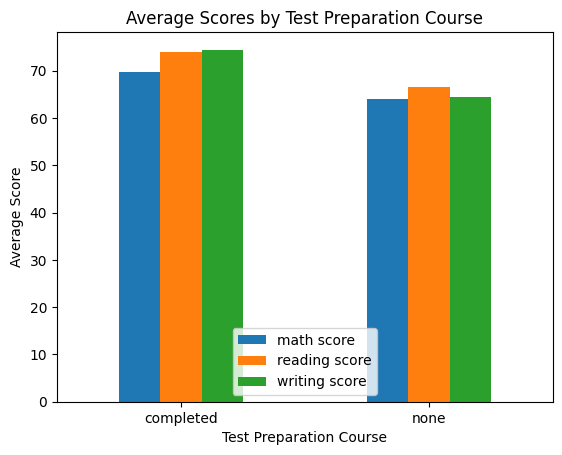

In [77]:
df.groupby("test preparation course")[["math score", "reading score", "writing score"]].mean()
df.groupby("test preparation course")[["math score", "reading score", "writing score"]].mean().plot(
    kind="bar"
)

plt.title("Average Scores by Test Preparation Course")
plt.ylabel("Average Score")
plt.xlabel("Test Preparation Course")
plt.xticks(rotation=0)
plt.show()

### Conclusion

Students who completed the test preparation course achieved higher average scores in math, reading, and writing than students who did not complete the course. This suggests that completing the test preparation course has a positive relationship with students' academic performance.

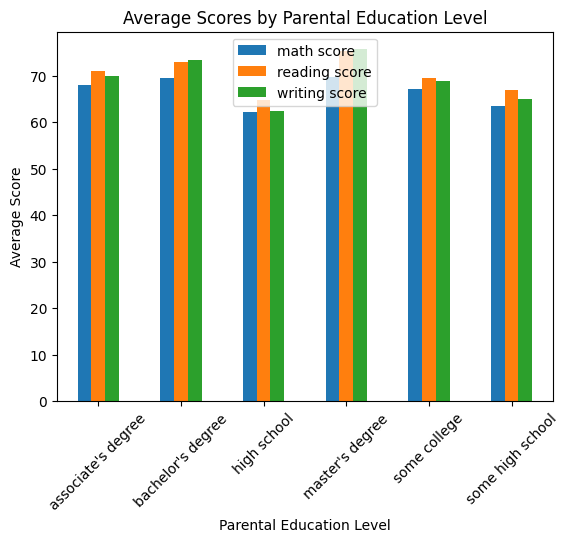

In [78]:
df.groupby("parental level of education")[
    ["math score", "reading score", "writing score"]
].mean()
df.groupby("parental level of education")[
    ["math score", "reading score", "writing score"]
].mean().plot(kind="bar")

plt.title("Average Scores by Parental Education Level")
plt.ylabel("Average Score")
plt.xlabel("Parental Education Level")
plt.xticks(rotation=45)
plt.show()

### Conclusion

Students whose parents have higher levels of education generally achieve higher average scores. Students with parents holding bachelor's or master's degrees show relatively high performance, while students whose parents have some high school education have lower average scores. This suggests a positive relationship between parental education level and student performance.

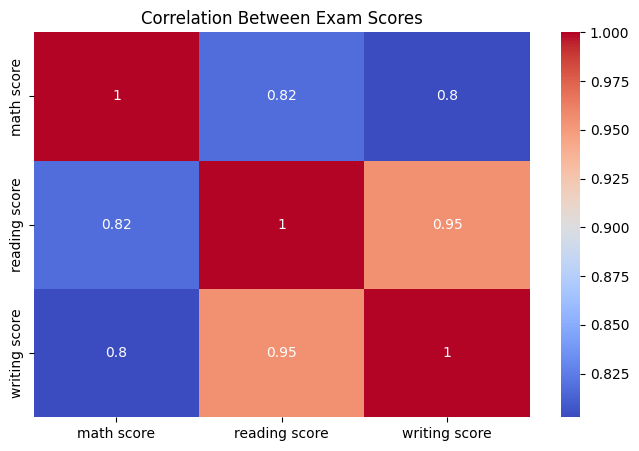

In [79]:
correlation = df[["math score", "reading score", "writing score"]].corr()

correlation
plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Exam Scores")
plt.show()

### Conclusion

There is a strong positive correlation between all three exam scores. Reading and writing have the strongest correlation (0.95), followed by math and reading (0.82), and math and writing (0.80). This means that students who perform well in one subject tend to perform well in the other subjects.

## 3. Data Cleaning and Wrangling

### 3.1 Checking for Duplicate Rows

In [80]:
df.duplicated().sum() # no duplecated
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

### Conclusion

Duplicate rows were checked and removed from the dataset to ensure that each student record is unique.

### 3.2 Checking for Missing Values

In [81]:
df.isnull().sum()
df.isnull().sum().sum()

np.int64(0)

### Conclusion

The dataset was checked for missing values. No missing values were found in any of the columns, so no imputation was required.

### encoding

In [82]:
df_encoded = df.copy()
categorical_columns = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

In [83]:
df_encoded = pd.get_dummies(
    df_encoded,
    columns=categorical_columns,
    drop_first=True
)

In [84]:
df_encoded.head()
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                                         Non-Null Count  Dtype
---  ------                                         --------------  -----
 0   math score                                     1000 non-null   int64
 1   reading score                                  1000 non-null   int64
 2   writing score                                  1000 non-null   int64
 3   gender_male                                    1000 non-null   bool 
 4   race/ethnicity_group B                         1000 non-null   bool 
 5   race/ethnicity_group C                         1000 non-null   bool 
 6   race/ethnicity_group D                         1000 non-null   bool 
 7   race/ethnicity_group E                         1000 non-null   bool 
 8   parental level of education_bachelor's degree  1000 non-null   bool 
 9   parental level of education_high school        1000 non-null   bool 
 10  p

### Conclusion

Categorical variables were converted into numerical features using one-hot encoding. This makes the categorical data suitable for numerical analysis and future machine learning tasks.

### Check for Invalid Scores / Outliers

In [85]:
score_columns = [
    "math score",
    "reading score",
    "writing score"
]
df[score_columns].agg(["min", "max"])

,math score,reading score,writing score
min,0,17,10
max,100,100,100


In [86]:
invalid_scores = (
    (df[score_columns] < 0) |
    (df[score_columns] > 100)
).any(axis=1)

invalid_scores.sum()

np.int64(0)

## 5. Parental Education and Student Performance

In [87]:
parental_scores = df.groupby("parental level of education")[
    ["math score", "reading score", "writing score"]
].mean().round(2)

parental_scores

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.88,70.93,69.90
bachelor's degree,69.39,73.00,73.38
high school,62.14,64.70,62.45
master's degree,69.75,75.37,75.68
some college,67.13,69.46,68.84
some high school,63.50,66.94,64.89


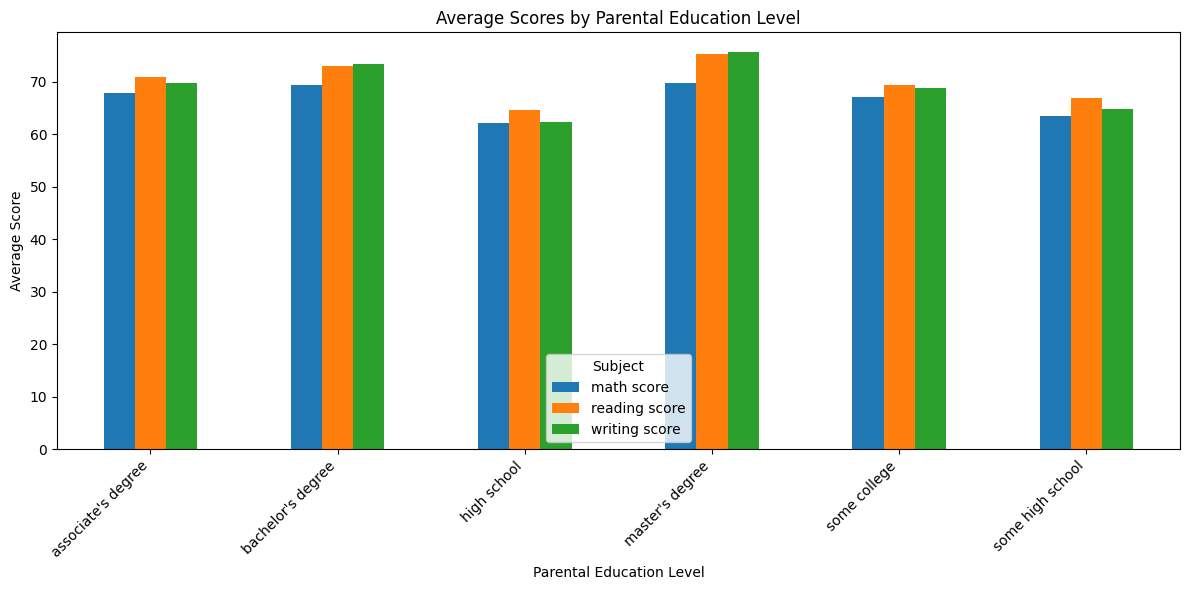

In [88]:
parental_scores.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Scores by Parental Education Level")
plt.xlabel("Parental Education Level")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Subject")
plt.tight_layout()
plt.show()

### Insight

Students' average scores vary across parental education levels.

Students whose parents have bachelor's or master's degrees generally show relatively high academic performance, while students whose parents have some high school education tend to have lower average scores.

This suggests that parental education level is associated with differences in students' academic performance.

### 6. Lunch Type and Academic Performance

In [89]:
lunch_scores = df.groupby("lunch")[
    ["math score", "reading score", "writing score"]
].mean().round(2)

lunch_scores

,math score,reading score,writing score
lunch,,,
free/reduced,58.92,64.65,63.02
standard,70.03,71.65,70.82


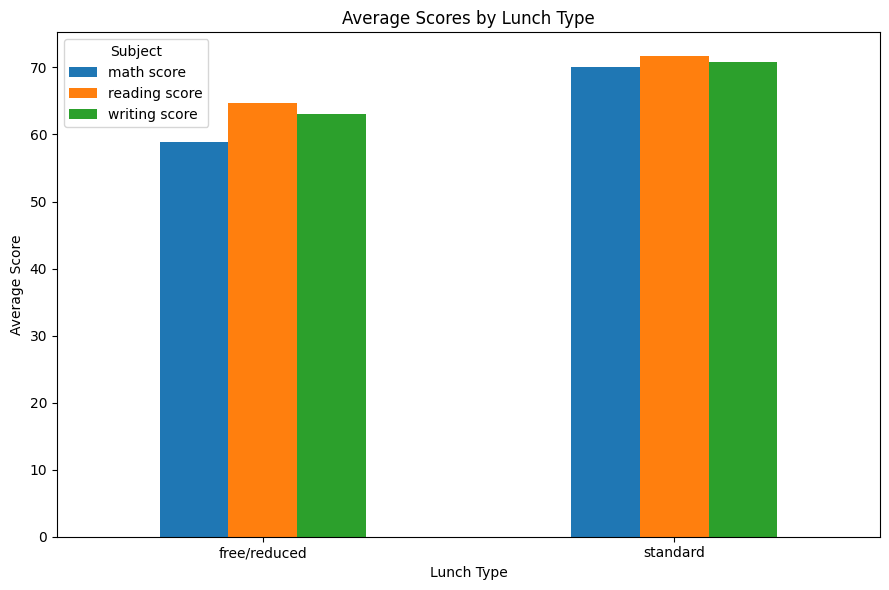

In [90]:
lunch_scores.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Average Scores by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subject")
plt.tight_layout()
plt.show()

### Insight

Students receiving standard lunch have higher average scores across math, reading, and writing compared with students receiving free or reduced-price lunch.

This indicates an association between lunch type and academic performance. However, lunch type may also reflect other socioeconomic factors, so this analysis does not establish a causal relationship.

## 7. Performance by Race/Ethnicity

In [91]:
race_scores = df.groupby("race/ethnicity")[
    ["math score", "reading score", "writing score"]
].mean().round(2)

race_scores

,math score,reading score,writing score
race/ethnicity,,,
group A,61.63,64.67,62.67
group B,63.45,67.35,65.60
group C,64.46,69.10,67.83
group D,67.36,70.03,70.15
group E,73.82,73.03,71.41


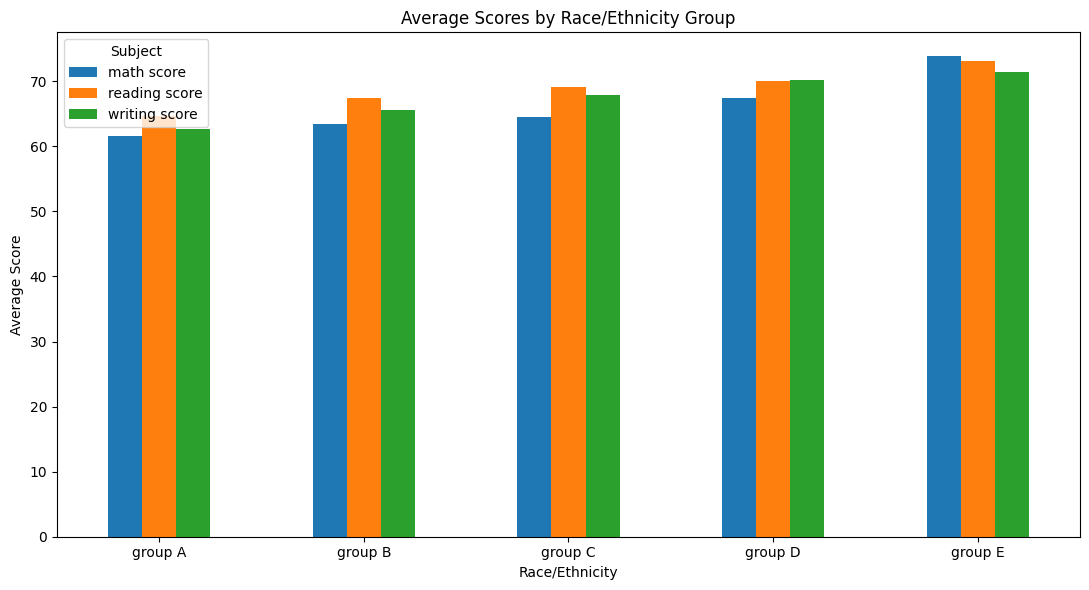

In [92]:
race_scores.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Average Scores by Race/Ethnicity Group")
plt.xlabel("Race/Ethnicity")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subject")
plt.tight_layout()
plt.show()

### Insight

Average academic performance differs across the race/ethnicity groups in the dataset.

The differences are visible across math, reading, and writing scores. These results describe patterns within this dataset and should not be interpreted as evidence that race or ethnicity causes differences in academic performance.

## 8. Overall Student Performance

In [93]:
df["overall_score"] = df[
    ["math score", "reading score", "writing score"]
].mean(axis=1)

df[["math score", "reading score", "writing score", "overall_score"]].head()

,math score,reading score,writing score,overall_score
0,72,72,74,72.666667
1,69,90,88,82.333333
2,90,95,93,92.666667
3,47,57,44,49.333333
4,76,78,75,76.333333


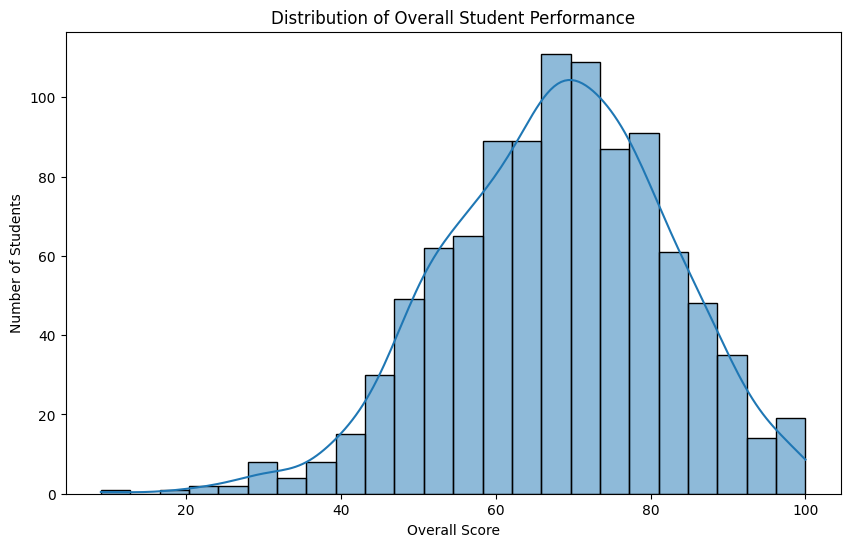

In [94]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["overall_score"],
    kde=True
)

plt.title("Distribution of Overall Student Performance")
plt.xlabel("Overall Score")
plt.ylabel("Number of Students")
plt.show()

In [95]:
print(f"Average Overall Score: {df['overall_score'].mean():.2f}")
print(f"Highest Overall Score: {df['overall_score'].max():.2f}")
print(f"Lowest Overall Score: {df['overall_score'].min():.2f}")

Average Overall Score: 67.77
Highest Overall Score: 100.00
Lowest Overall Score: 9.00


### Insight

The overall score provides a combined measure of students' performance across math, reading, and writing.

The distribution shows that most students' overall performance is concentrated around the middle-to-upper range of the scoring scale, with some variation between students.

In [96]:
top_students = df.sort_values(
    "overall_score",
    ascending=False
).head(10)

top_students[
    ["gender", "race/ethnicity", "parental level of education",
     "test preparation course", "overall_score"]
]

,gender,race/ethnicity,parental level of education,test preparation course,overall_score
916,male,group E,bachelor's degree,completed,100.000000
962,female,group E,associate's degree,none,100.000000
458,female,group E,bachelor's degree,none,100.000000
114,female,group E,bachelor's degree,completed,99.666667
712,female,group D,some college,none,99.000000
179,female,group D,some high school,completed,99.000000
165,female,group C,bachelor's degree,completed,98.666667
625,male,group D,some college,completed,98.666667
685,female,group E,master's degree,completed,97.666667
903,female,group D,bachelor's degree,completed,97.666667


In [97]:
bottom_students = df.sort_values(
    "overall_score"
).head(10)

bottom_students[
    ["gender", "race/ethnicity", "parental level of education",
     "test preparation course", "overall_score"]
]

,gender,race/ethnicity,parental level of education,test preparation course,overall_score
59,female,group C,some high school,none,9.000000
980,female,group B,high school,none,18.333333
596,male,group B,high school,none,23.000000
327,male,group A,some college,none,23.333333
17,female,group B,some high school,none,26.000000
76,male,group E,some high school,none,26.000000
601,female,group C,high school,none,29.333333
338,female,group B,some high school,none,29.666667
787,female,group B,some college,none,29.666667
211,male,group C,some college,none,30.000000


## 9. Key Findings

The analysis revealed several important patterns in students' academic performance.

In [98]:
print("KEY FINDINGS")
print("=" * 50)

print(f"1. Overall average score: {df['overall_score'].mean():.2f}")

print(
    f"2. Test preparation completion rate: "
    f"{df['test preparation course'].eq('completed').mean() * 100:.2f}%"
)

print(
    f"3. Test preparation was associated with higher scores in all three subjects."
)

print(
    f"4. The largest improvement after test preparation was in writing "
    f"({percentage_improvement['writing score']:.2f}%)."
)

print(
    f"5. Reading and writing had the strongest correlation "
    f"({df['reading score'].corr(df['writing score']):.2f})."
)

print(
    f"6. Female students had higher average reading and writing scores, "
    f"while male students had a higher average math score."
)

KEY FINDINGS
1. Overall average score: 67.77
2. Test preparation completion rate: 35.80%
3. Test preparation was associated with higher scores in all three subjects.
4. The largest improvement after test preparation was in writing (15.37%).
5. Reading and writing had the strongest correlation (0.95).
6. Female students had higher average reading and writing scores, while male students had a higher average math score.


## 11. Recommendations

Based on the analysis, the following recommendations can be considered:

1. Encourage students to complete test preparation courses, as completion was associated with higher average performance across all three subjects.

2. Give additional attention to writing and reading skills, especially because these subjects showed strong relationships with overall academic performance.

3. Consider providing additional academic support to students with lower overall performance.

4. Use student performance data to identify groups that may benefit from additional learning resources.

5. Future analysis should include additional variables and statistical testing to better understand the factors associated with academic performance.

### Important Note

The findings in this project describe associations and patterns in the dataset. They should not be interpreted as proof of causal relationships.

# 12. Final Conclusion

This project analyzed the academic performance of 1,000 students across mathematics, reading, and writing.

The analysis included data inspection, cleaning, exploratory data analysis, categorical encoding, statistical summaries, correlation analysis, and data visualization.

The results showed that students who completed the test preparation course achieved higher average scores across all three subjects. Differences were also observed across gender, parental education level, lunch type, and race/ethnicity groups.

Reading and writing showed the strongest relationship among the three subjects, with a correlation of approximately 0.95.

Overall, the analysis demonstrates how Python and data analysis techniques can be used to identify meaningful patterns in educational data and support data-driven decision making.